## Update forcing conditions to model from Python

In this example, the previously made **SFINCS** compound flood model will be updated with more boundary conditions..

The model is situated in **Northern Italy**, where a small selection of topography and bathymetry data has already been made available for you to try the examples.

In [1]:
from hydromt_sfincs import SfincsModel
from hydromt._utils import log

# Initialize logging, the lower the log level number, the more verbose (more info) the output
# NOTSET=0-9, DEBUG=10, INFO=20, WARNING=30, ERROR=40, CRITICAL=50

log.initialize_logging()
log.set_log_level(log_level=20)

**Steps followed in this notebook to update your SFINCS model:**
<ol> 
<li> Initialize SfincsModel class, set data library, mode and root folder </li>
<li> Add an upstream discharge time-series as forcing</li>
<li> Add spatially varying rainfall data</li>
<li> Add infiltration to the model</li>
<li> Save all files</li>
</ol> 

Let's get started!

### 1. Initialize SfincsModel class, set data library, mode and root folder:

Before we can use all the tools provided by HydroMT-SFINCS, we have to initialize the SfincsModel instance. This creates a shortcut to all the model components and methods to read, write and create these components.

In contrast to the previous notebook, we now initialize the model in "append" mode: "r+", to make sure we can upgrade some of its components.

In [ ]:
# Initialize SfincsModel Python class with the artifact data catalog which contains publically available data for North Italy
sf = SfincsModel(
    data_libs=["artifact_data"],  # specify which data libraries to use
    root="tmp_sfincs_compound",  # specify the root directory for the model
    mode="r+",  # specify the mode for opening the model (r=read only, r+=append, w=write, w+=overwrite
    write_gis=True,  # specify whether to write GIS data
)

2025-11-22 17:22:11,869 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2025-11-22 17:22:11,869 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\asselt\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2025-11-22 17:22:12,644 - hydromt.model.model - model - INFO - Initializing sfincs model from hydromt_sfincs (v2.0.0.dev0).
2025-11-22 17:22:12,645 - hydromt.model.model - model - WARNING - No region component found in components.


### 2. Add an upstream discharge time-series as forcing:
Similar to the water levels, there is many ways to specify the [discharge points](https://sfincs.readthedocs.io/en/latest/input_forcing.html#discharge-points) and the [discahrge timeseries](https://sfincs.readthedocs.io/en/latest/input_forcing.html#discharge-time-series), but only one will be discussed here.

2025-11-22 17:22:33,515 - hydromt.hydromt_sfincs.components.forcing.boundary_conditions - boundary_conditions - INFO - Removed 1 duplicate points based on 'name' or geometry.


2025-11-22 17:22:35,112 - hydromt.hydromt_sfincs.components.grid.subgrid - subgrid - INFO - No subgrid table available to write.
2025-11-22 17:22:35,242 - hydromt.hydromt_sfincs.utils - utils - INFO - No changes detected; skipping write to C:\git\hydromt_sfincs\examples\sfincs_compound_new\sfincs_netbndbzsbzifile.nc


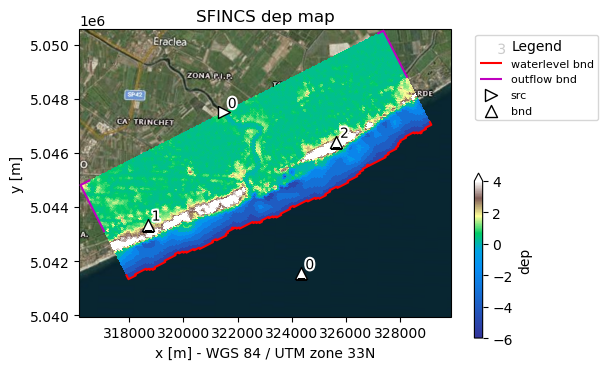

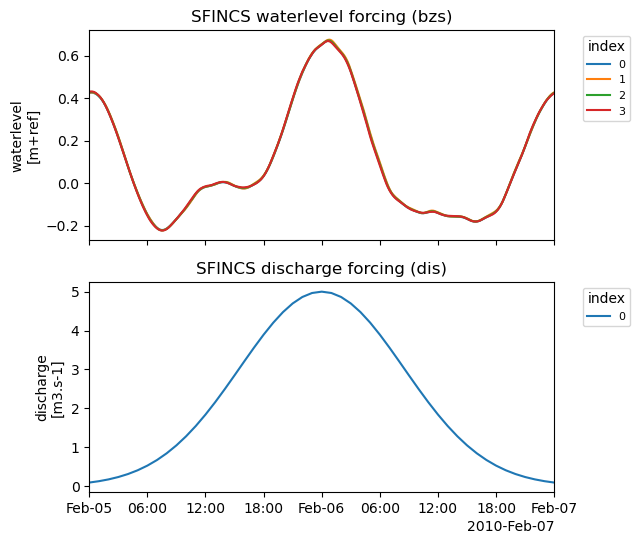

In [4]:
# optionally, points can be added manually
sf.discharge_points.add_point(
    x=321483.2, y=5047503.0, value=1000.0, name="Piave_inflow"
)

sf.discharge_points.create_timeseries(
    index=[0],
    shape="gaussian",
    offset=0,
    peak=5,
    tpeak=86400,
    duration=2 * 86400,
    timestep=3600,
)
# and plot
sf.plot_basemap(
    variable="dep", plot_geoms=True, plot_bounds=True, bmap="sat", zoomlevel=12
)
sf.plot_forcing()

### 3. Add spatially varying rainfall data:

2025-11-22 16:55:27,169 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading era5_hourly RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\era5_hourly.nc


2025-11-22 16:55:27,274 - hydromt.hydromt_sfincs.components.forcing.meteo - meteo - WARNING - Replacing grid map: precip_2d


(<Figure size 600x900 with 3 Axes>,
 array([<Axes: title={'center': 'SFINCS waterlevel forcing (bzs)'}, ylabel='waterlevel\n[m+ref]'>,
        <Axes: title={'center': 'SFINCS discharge forcing (dis)'}, ylabel='discharge\n[m3.s-1]'>,
        <Axes: title={'center': 'SFINCS precipitation forcing (precip_2d)'}, ylabel='mean precipitation\n[mm.hr-1]'>],
       dtype=object))

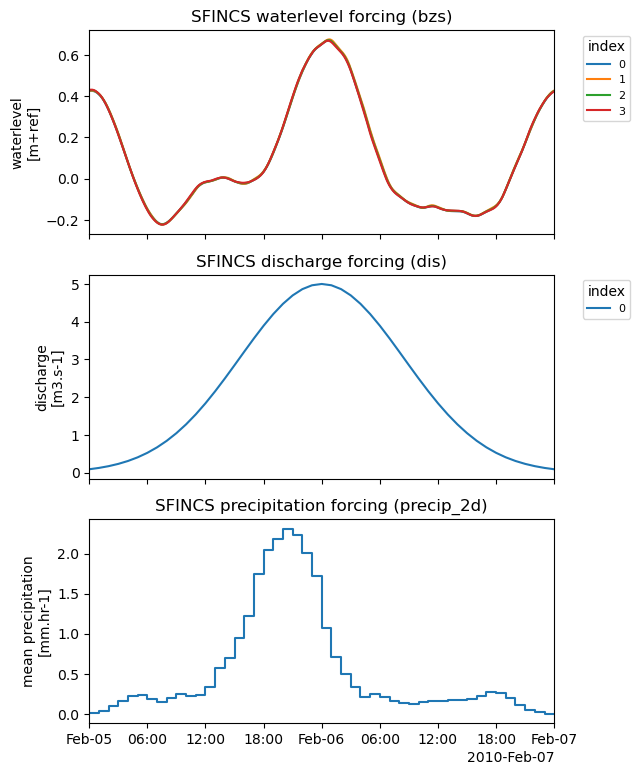

In [ ]:
# # hourly rainfall rates of ECMWF' ERA5 data for the specific area and period have been made available for this period in the artefact data
sf.precipitation.create(precip="era5_hourly", aggregate=False, buffer=30e3)

# NOTE: when specifying an output name, the image is also saved to file
sf.plot_forcing(fn_out="forcing.png")

<div style="border-left: 4px solid #4CAF50; padding: 10px; margin: 5px 0; background-color: #f0fff0;">
<b>💡 Tip:</b> In case you want to add other types of forcing, read more in the <a href="https://sfincs.readthedocs.io/en/latest/input_forcing.html" target="_blank">SFINCS manual</a>.
</div>


### 4. Add spatially varying infiltration data:

SFINCS (and HydroMT-SFINCS) contains a couple of different methods to specify infiltration. In the example below, the curve number method is used, but we recommend to checkout the documentation to explore other options. Note that curve number infiltration only works when the model is forced with precipitation.

2025-11-22 16:57:00,063 - hydromt.hydromt_sfincs.components.grid.infiltration - infiltration - INFO - Creating curve number values for SFINCS with antecedent moisture condition: avg.
2025-11-22 16:57:00,075 - hydromt.data_catalog.sources.data_source - data_source - INFO - Reading gcn250 RasterDataset data from C:\Users\asselt\.hydromt\artifact_data\latest\gcn250\{variable}.tif
2025-11-22 16:57:00,222 - hydromt.model.components.grid - grid - WARNING - Replacing grid map: scs


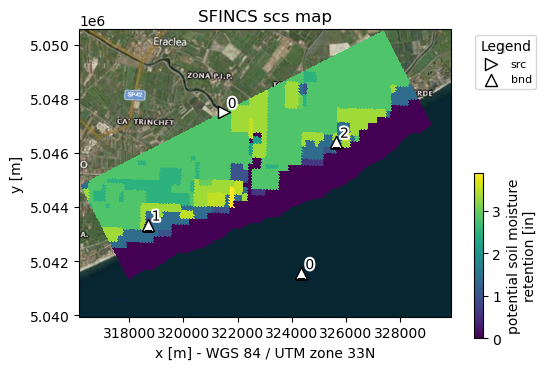

In [9]:
# independent from subgrid files
# curve number infiltration based on global CN dataset
sf.infiltration.create_cn("gcn250", antecedent_moisture="avg")

_ = sf.plot_basemap(variable="scs", plot_bounds=False, bmap="sat", zoomlevel=12)

### 5. Write all files

In [10]:
sf.write() 

2025-11-22 16:57:10,308 - hydromt.hydromt_sfincs.utils - utils - INFO - No changes detected; skipping write to C:\git\hydromt_sfincs\examples\tmp_sfincs_compound\sfincs_netbndbzsbzifile.nc


Now your model has new boundary conditions, you can progress (or run again) to the notebook: [Run SFINCS model](4_run_model.ipynb). In case you want to add some geometries and structures to your model first, continue with notebook [Update Geometries](3_add_geometries.ipynb)